Claudio Xavier Bayro Jablonski 731886
## Text Extractor with Map-Reduce


In [57]:
!apt-get update
!apt-get install -y tesseract-ocr
!pip install pytesseract pillow opencv-python

Hit:1 http://ports.ubuntu.com/ubuntu-ports jammy InRelease
Hit:2 http://ports.ubuntu.com/ubuntu-ports jammy-updates InRelease
Hit:3 http://ports.ubuntu.com/ubuntu-ports jammy-backports InRelease
Hit:4 http://ports.ubuntu.com/ubuntu-ports jammy-security InRelease
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.


In [58]:
!apt-get update
!apt-get install -y libgl1

Hit:1 http://ports.ubuntu.com/ubuntu-ports jammy InRelease
Hit:2 http://ports.ubuntu.com/ubuntu-ports jammy-updates InRelease
Hit:3 http://ports.ubuntu.com/ubuntu-ports jammy-backports InRelease
Hit:4 http://ports.ubuntu.com/ubuntu-ports jammy-security InRelease
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgl1 is already the newest version (1.4.0-1).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.


In [59]:
!tesseract --version

tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8


In [60]:
import pytesseract
import PIL
import cv2

print("ALL GOOD")

ALL GOOD


In [61]:
import os
import re
import cv2
import pytesseract

from PIL import Image
from pyspark.sql import SparkSession

In [62]:
!pip install pyspark

## Input Data

The input of this notebook is a set of image files containing text.

These files should be placed in the shared `data` folder of the Spark container.

Expected folder inside the container:

`/opt/spark/work-dir/data`

Supported formats:
- PNG
- JPG
- JPEG
- BMP
- TIFF

In [63]:
spark = SparkSession.builder \
    .appName("TextExtractorMapReduce") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext

print("Spark started successfully")
print("Spark version:", spark.version)

Spark started successfully
Spark version: 4.0.1


In [64]:
images_folder = "/opt/spark/work-dir/data"
supported_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".tiff")

image_paths = []

if os.path.exists(images_folder):
    image_paths = [
        os.path.join(images_folder, file)
        for file in os.listdir(images_folder)
        if file.lower().endswith(supported_extensions)
    ]

print("Images found:", len(image_paths))
for path in image_paths:
    print(path)

Images found: 3
/opt/spark/work-dir/data/xd.png
/opt/spark/work-dir/data/lab1.png
/opt/spark/work-dir/data/d.png


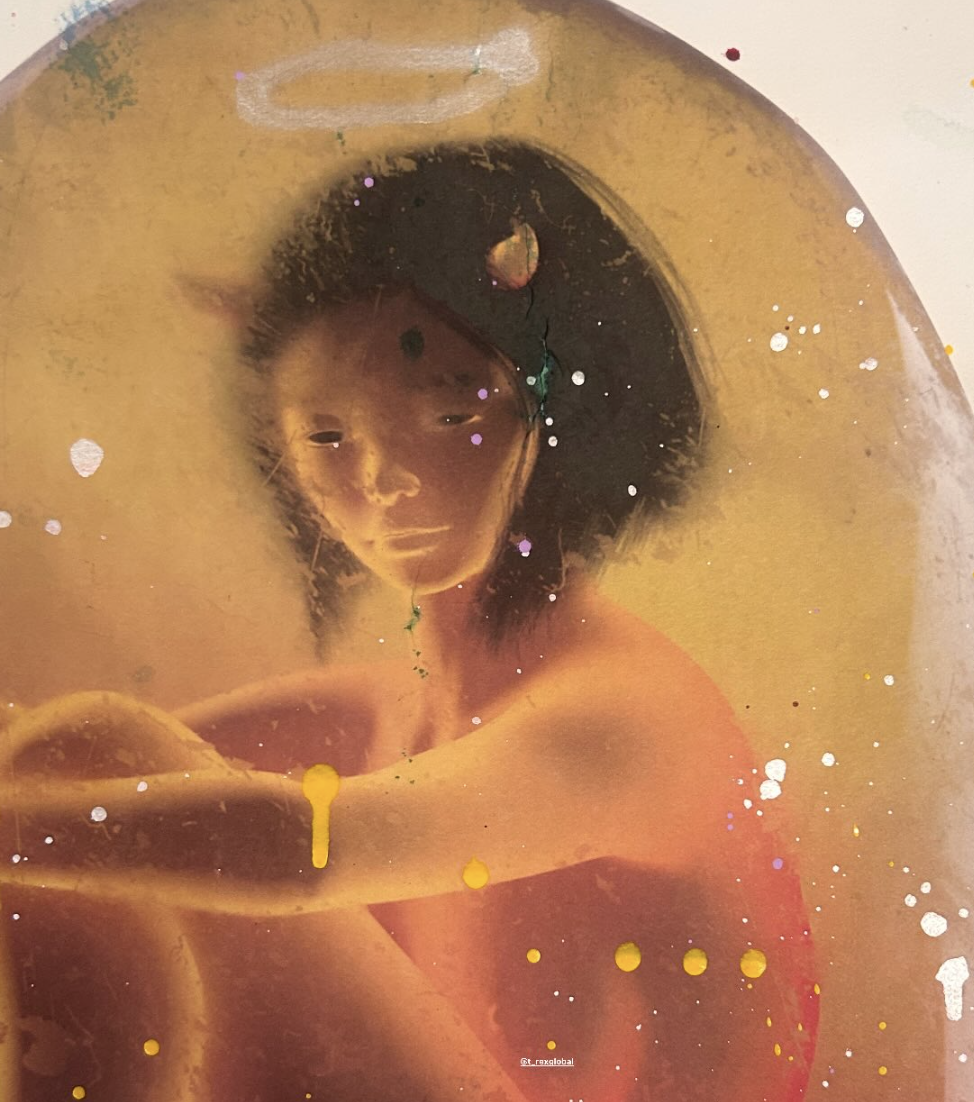

In [65]:
if len(image_paths) > 0:
    display(Image.open(image_paths[0]))
else:
    print("No images found in the data folder.")

## Image Preprocessing

Before OCR, each image is preprocessed to improve text extraction accuracy.

The preprocessing includes:
- reading the image
- converting it to grayscale
- applying Gaussian blur
- applying thresholding

In [66]:
def preprocess_image(image_path):
    img = cv2.imread(image_path)

    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

    return thresh

In [67]:
def extract_text_from_image(image_path):
    try:
        processed = preprocess_image(image_path)

        if processed is None:
            return (os.path.basename(image_path), "ERROR: Could not read image")

        text = pytesseract.image_to_string(processed)
        text = text.strip()

        return (os.path.basename(image_path), text)

    except Exception as e:
        return (os.path.basename(image_path), f"ERROR: {str(e)}")

In [68]:
if len(image_paths) > 0:
    filename, extracted_text = extract_text_from_image(image_paths[0])
    print("File:", filename)
    print("\nExtracted Text:\n")
    print(extracted_text)
else:
    print("No images available for OCR test.")

File: xd.png

Extracted Text:




## Map-Reduce Strategy

This notebook uses the Map-Reduce model in Apache Spark.

### Map Phase
Each image path is mapped into a `(file_name, extracted_text)` pair by applying OCR.

### Reduce Phase
The extracted text is split into words and reduced by key to calculate word frequencies across all documents.

In [69]:
images_rdd = sc.parallelize(image_paths)

print("RDD created with", images_rdd.count(), "image(s)")

RDD created with 3 image(s)


In [70]:
ocr_results_rdd = images_rdd.map(extract_text_from_image)
ocr_results = ocr_results_rdd.collect()

for file_name, text in ocr_results:
    print("=" * 70)
    print("File:", file_name)
    print("Extracted text:")
    print(text[:1000] if text else "[No text found]")
    print()

File: xd.png
Extracted text:
[No text found]

File: lab1.png
Extracted text:
Lab 01: Student Collaboration Analyzer

Task 2: Collaboration Frequency (Dictionaries)

Create a branch based on your own branch

Task 2: Unique Students (Sets)

Return the set of all unique students involved in all collaborations.
@ Use a set to avoid duplicate student IDs.

@ Iterate over all collaboration records.

Task 3: Collaboration Frequency (Dictionaries)

Compute how many times each pair of students collaborated together.

@ Each collaboration pair should be order-independent (e.g., (s0001, s0002)
is the same as (s0002, s0001)).

@ Use adictionary to count occurrences.

File: d.png
Extracted text:
[No text found]



In [71]:
ocr_results_rdd = images_rdd.map(extract_text_from_image)
ocr_results = ocr_results_rdd.collect()

for file_name, text in ocr_results:
    print("=" * 70)
    print("File:", file_name)
    print("Extracted text:")
    print(text[:1000] if text else "[No text found]")
    print()

File: xd.png
Extracted text:
[No text found]

File: lab1.png
Extracted text:
Lab 01: Student Collaboration Analyzer

Task 2: Collaboration Frequency (Dictionaries)

Create a branch based on your own branch

Task 2: Unique Students (Sets)

Return the set of all unique students involved in all collaborations.
@ Use a set to avoid duplicate student IDs.

@ Iterate over all collaboration records.

Task 3: Collaboration Frequency (Dictionaries)

Compute how many times each pair of students collaborated together.

@ Each collaboration pair should be order-independent (e.g., (s0001, s0002)
is the same as (s0002, s0001)).

@ Use adictionary to count occurrences.

File: d.png
Extracted text:
[No text found]



In [72]:
ocr_df = spark.createDataFrame(ocr_results, ["file_name", "extracted_text"])
ocr_df.show(truncate=False)

+---------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|file_name|extracted_text                                                                                                                                                                                                                                                                                                                                                                     

In [73]:
def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9áéíóúüñÁÉÍÓÚÜÑ\s]", " ", text)
    words = text.split()
    return [word for word in words if word.strip() != ""]

In [74]:
word_counts_rdd = ocr_results_rdd \
    .flatMap(lambda x: clean_and_tokenize(x[1])) \
    .map(lambda word: (word, 1)) \
    .reduceByKey(lambda a, b: a + b) \
    .sortBy(lambda x: x[1], ascending=False)

top_words = word_counts_rdd.take(20)

print("Top 20 most frequent words:\n")
for word, count in top_words:
    print(f"{word}: {count}")

Top 20 most frequent words:

collaboration: 5
students: 3
all: 3
task: 3
set: 2
to: 2
pair: 2
use: 2
student: 2
of: 2
2: 2
unique: 2
frequency: 2
s0002: 2
branch: 2
the: 2
a: 2
each: 2
dictionaries: 2
s0001: 2


In [75]:
file_word_counts_rdd = ocr_results_rdd.flatMap(
    lambda x: [((x[0], word), 1) for word in clean_and_tokenize(x[1])]
).reduceByKey(lambda a, b: a + b)

file_word_counts = file_word_counts_rdd.collect()

for item, count in file_word_counts[:50]:
    print(item, "->", count)

('lab1.png', 'your') -> 1
('lab1.png', 'involved') -> 1
('lab1.png', 'pair') -> 2
('lab1.png', 'be') -> 1
('lab1.png', 'sets') -> 1
('lab1.png', 'g') -> 1
('lab1.png', 'students') -> 3
('lab1.png', 'all') -> 3
('lab1.png', 'ids') -> 1
('lab1.png', 'compute') -> 1
('lab1.png', 'each') -> 2
('lab1.png', 'collaborated') -> 1
('lab1.png', 's0002') -> 2
('lab1.png', '2') -> 2
('lab1.png', 'times') -> 1
('lab1.png', 'a') -> 2
('lab1.png', 'branch') -> 2
('lab1.png', 'on') -> 1
('lab1.png', 'unique') -> 2
('lab1.png', 'to') -> 2
('lab1.png', 'duplicate') -> 1
('lab1.png', 'over') -> 1
('lab1.png', 'records') -> 1
('lab1.png', '3') -> 1
('lab1.png', 'should') -> 1
('lab1.png', 'same') -> 1
('lab1.png', 'lab') -> 1
('lab1.png', 'student') -> 2
('lab1.png', 'set') -> 2
('lab1.png', 'analyzer') -> 1
('lab1.png', 'dictionaries') -> 2
('lab1.png', 'avoid') -> 1
('lab1.png', 'how') -> 1
('lab1.png', 'order') -> 1
('lab1.png', 'e') -> 1
('lab1.png', 'occurrences') -> 1
('lab1.png', 'based') -> 1
('la

In [76]:
text_stats_rdd = ocr_results_rdd.map(
    lambda x: (x[0], len(x[1]), len(clean_and_tokenize(x[1])))
)

text_stats_df = spark.createDataFrame(
    text_stats_rdd,
    ["file_name", "num_characters", "num_words"]
)

text_stats_df.show(truncate=False)

+---------+--------------+---------+
|file_name|num_characters|num_words|
+---------+--------------+---------+
|xd.png   |0             |0        |
|lab1.png |585           |84       |
|d.png    |0             |0        |
+---------+--------------+---------+



## Saving Results

The OCR output and text analysis results are saved for later review.

In [77]:
output_folder = "/opt/spark/work-dir/data/output"
os.makedirs(output_folder, exist_ok=True)

output_text_file = os.path.join(output_folder, "ocr_results.txt")

with open(output_text_file, "w", encoding="utf-8") as f:
    for file_name, text in ocr_results:
        f.write("=" * 80 + "\n")
        f.write(f"FILE: {file_name}\n")
        f.write("=" * 80 + "\n")
        f.write(text + "\n\n")

print("OCR results saved to:", output_text_file)

OCR results saved to: /opt/spark/work-dir/data/output/ocr_results.txt


In [78]:
word_counts_data = word_counts_rdd.collect()

if len(word_counts_data) == 0:
    print("No words were extracted, so no CSV was generated.")
else:
    word_counts_df = spark.createDataFrame(word_counts_data, ["word", "count"])
    word_counts_output = os.path.join(output_folder, "word_counts.csv")

    word_counts_df.coalesce(1).write.mode("overwrite").csv(word_counts_output, header=True)

    print("Word counts saved to:", word_counts_output)

Word counts saved to: /opt/spark/work-dir/data/output/word_counts.csv


## Conclusion

This notebook successfully implements a text extractor using Apache Spark and the Map-Reduce paradigm.

### Results
- Image files were loaded from the shared data folder
- OCR was applied using Tesseract
- Spark processed the images in parallel
- Word frequency analysis was performed using Map-Reduce

### Final Outcome
The system demonstrates how Spark can be used to distribute text extraction and text analysis tasks efficiently.

In [79]:
spark.stop()
print("Spark session stopped")

Spark session stopped
